# MIS: Clase Complementaria 5 (2025-20)

Hoy nos centraremos en lo que se conoce como Medidas Espectrales. Así, usaremos propiedades de la matriz de Adyacencia de un grafo para poder determinar la importancia de un nodo.

En particular, trataremos las medidas:

1. Prestigio de Katz.
2. Centralidad de Bonanich.

Discutiremos condiciones de entrega del taller y les enseñaré a pensar en términos de matrices algunos conceptos clave.

### Taller e impresiones hasta el momento (5-10 min):

1. Taller está pensado para una semana, desde el momento en que se los suba. ¿Qué tipo de Dataset les gustaría usar?
2. Opiniones, quejas, reclamos, etc. Relacionados con la magistral y complementaria. (Es útil retroalimentar en este momento).

### Ahora si, al contenido de la clase:

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import itertools as it
import time
import matplotlib.pyplot as plt
import graph_tools
import random
#import scipy.linalg as linalg 
#py -m pip install scipy==1.8.1


#### ¿Por qué hablamos de Medidas Espectrales?

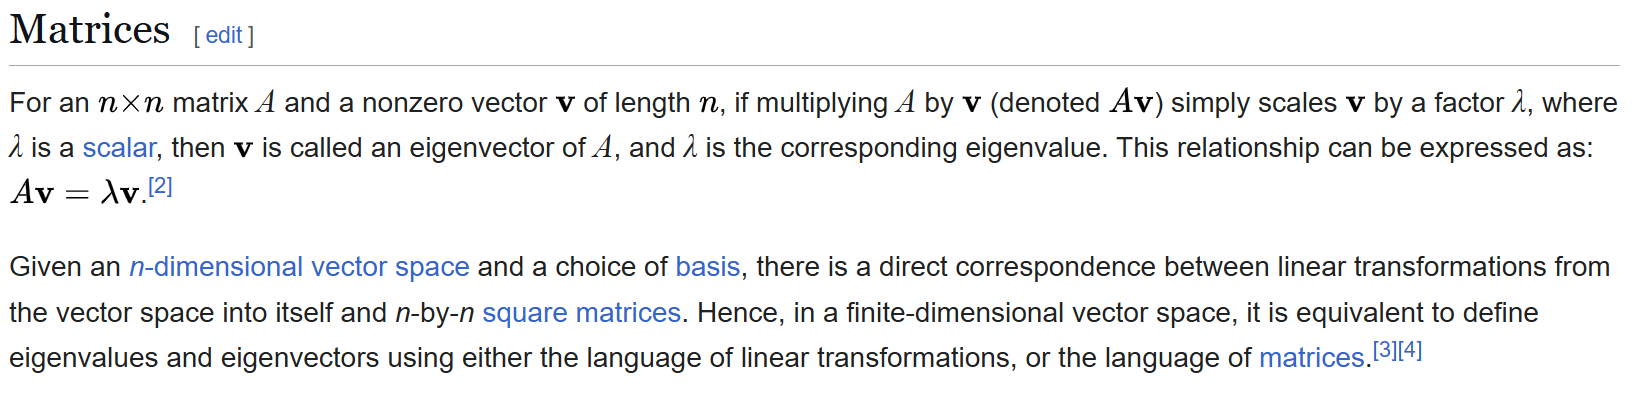

Si quiere consultar más puede dirigirse a: https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors

#### Prestigio de Katz 

Tenemos una medida de qué tan importante es un nodo basado en la importancia de sus vecinos.

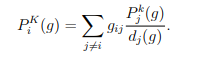

(Ojo: No confundir con Centralidad de Katz de la literatura)

In [2]:
# Ejemplos de Matrices
M = [[0.5,0.5],[0.1,0.9]]
N = [[0.9,0.09],[0.4,0.6]] 
U = [[0.4,0.6],[0.9,0]]

n = 10
Matriz0 = np.array([[random.randint(0,1) for i in range(n)] for j in range(n)])
Matriz0 = Matriz0 - np.diag(Matriz0.diagonal())
Triang = np.triu(Matriz0)
Matriz1 = Triang+Triang.T
Norm = Matriz1.sum(axis = 1)
Matriz = np.array([Matriz1[:,j]/Norm[j] for j in range(n)])



In [3]:
# Calculo de autovalores y autovectores
Katz = np.linalg.eig(M)
print(Katz)

EigResult(eigenvalues=array([0.4, 1. ]), eigenvectors=array([[-0.98058068, -0.70710678],
       [ 0.19611614, -0.70710678]]))


In [4]:
# Es buena aproximación?
index = [i for i in range(2) if Katz[0][i] == 1][0]
v = Katz[1][index]
derecha = M@v
Medida = v-derecha
print("Medida de error {}".format(np.abs(Medida).sum()))
print(np.abs(Medida))
print(v)
print(derecha)


Medida de error 0.5419337497948389
[0.45161146 0.09032229]
[ 0.19611614 -0.70710678]
[-0.25549532 -0.61678449]


In [5]:
# Será que calculamos Katz en esta?
Katz = np.linalg.eig(Matriz)
print(Katz)

EigResult(eigenvalues=array([ 1.00000000e+00, -7.37835346e-01,  4.18044363e-01, -3.87802607e-01,
       -2.73378271e-01, -2.22030948e-01,  1.58967877e-01,  1.06693240e-01,
       -6.26583081e-02,  2.30408438e-18]), eigenvectors=array([[ 3.16227766e-01,  1.65924069e-01,  3.66656341e-01,
        -3.54175564e-01,  1.67774646e-01, -6.78917440e-01,
         3.47734364e-02, -2.72186105e-01,  4.35392631e-02,
        -4.60001500e-18],
       [ 3.16227766e-01,  2.66915189e-01,  2.29927555e-01,
         6.41367791e-02,  3.62571265e-01,  4.79928423e-01,
        -3.38012155e-01, -9.66756613e-03,  2.28874864e-01,
        -5.02764275e-17],
       [ 3.16227766e-01, -2.78437721e-01,  2.81773827e-01,
         4.21614114e-01, -1.30520281e-01, -1.14853575e-01,
         1.08912545e-01,  2.39419365e-01,  1.23481439e-01,
         7.07106781e-01],
       [ 3.16227766e-01, -3.50371087e-01, -5.13327891e-01,
        -9.15728055e-02,  7.51957761e-01, -4.77828721e-03,
         4.85308858e-01,  5.66913100e-02,  3.

In [6]:
# Es buena aproximación?
v = Katz[1][0]
derecha = Matriz@v
Medida = v-derecha
print("Medida de error {}".format(np.abs(Medida).sum()))
print(np.abs(Medida))
print(v)
print(derecha)

Medida de error 2.2948215066459157
[0.25544105 0.08442229 0.40496293 0.19830772 0.23674036 0.64868534
 0.14984634 0.23387952 0.0796263  0.00290966]
[ 3.16227766e-01  1.65924069e-01  3.66656341e-01 -3.54175564e-01
  1.67774646e-01 -6.78917440e-01  3.47734364e-02 -2.72186105e-01
  4.35392631e-02 -4.60001500e-18]
[ 0.06078671  0.08150178 -0.03830659 -0.15586784 -0.06896572 -0.0302321
 -0.11507291 -0.03830659 -0.03608704  0.00290966]


La enseñanza de esto último no es que la medida es mala, sino que ejemplifica los problemas de los cálculos numéricos en los computadores y nos enseña que debemos ser conscientes de ellos. Como economistas no debemos ser expertos en esta materia, pero si es responsabilidad nuestra saber que este tipo de inconsistencias pueden existir.

#### Bonanich

Ahora tenemos la medida de Centralidad de Bonanich o Centralidad de Autovector.

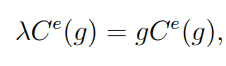

In [7]:
# Calculo de autovalores y autovectores
Bonanich = np.linalg.eig(Matriz1)
print(Bonanich)

EigResult(eigenvalues=array([ 5.17258286e+00, -3.31916225e+00,  1.67522444e+00, -1.95154319e+00,
       -1.26400841e+00, -1.12478421e+00,  4.96255584e-01,  6.34044533e-01,
       -3.18609368e-01, -1.58512757e-17]), eigenvectors=array([[ 3.40438527e-01,  2.05664443e-01,  3.98640235e-01,
        -1.26120554e-01,  7.04771792e-01, -2.99895945e-01,
         2.67454360e-01,  4.61767864e-02, -8.17210422e-02,
         3.10278658e-17],
       [ 3.69950502e-01,  3.53390684e-01,  2.99057103e-01,
         1.78209479e-01, -1.66410441e-01,  6.15793621e-01,
        -1.11734540e-01,  3.79278315e-01, -2.32006499e-01,
         1.35874038e-16],
       [ 2.93660927e-01, -3.03497160e-01,  2.46171500e-01,
         3.17802956e-01, -1.56421842e-01, -2.14211142e-01,
        -1.88558588e-01, -1.98122490e-01, -1.22034990e-01,
         7.07106781e-01],
       [ 2.00669706e-01, -2.25581717e-01, -4.80489466e-01,
         1.61915876e-01,  4.16570687e-01,  4.52565627e-01,
         9.22069124e-02, -4.03256474e-01, -3.

In [8]:
Lambda_Abs = np.abs(Bonanich[0])

In [9]:
# Identificación del radio espectral (i.e. el autovalor más grande en valor absoluto)
Lambda_Abs = np.abs(Bonanich[0])
radio_espectral = Lambda_Abs.max()
indice = 0
for i in range(len(Lambda_Abs)):
    if Lambda_Abs[i] == radio_espectral:
        indice = i
        break
print(indice)

0


In [10]:
# Identificación de Bonanich
autovalor = Bonanich[0][indice]
autovector = Bonanich[1][indice]
print(f'El autovalor es {autovalor}\n\nEl autovector es: {autovector}')
# ¿Qué nos dice esto en términos de importancia de los nodos?
# ¿Cambia algo si tenemos autovalores negativos como Radio Espectral?

El autovalor es 5.172582862082616

El autovector es: [ 3.40438527e-01  2.05664443e-01  3.98640235e-01 -1.26120554e-01
  7.04771792e-01 -2.99895945e-01  2.67454360e-01  4.61767864e-02
 -8.17210422e-02  3.10278658e-17]


Chevere los vectores que sacamos, pero ¿qué significan? Preste atención al siguiente desarrollo:

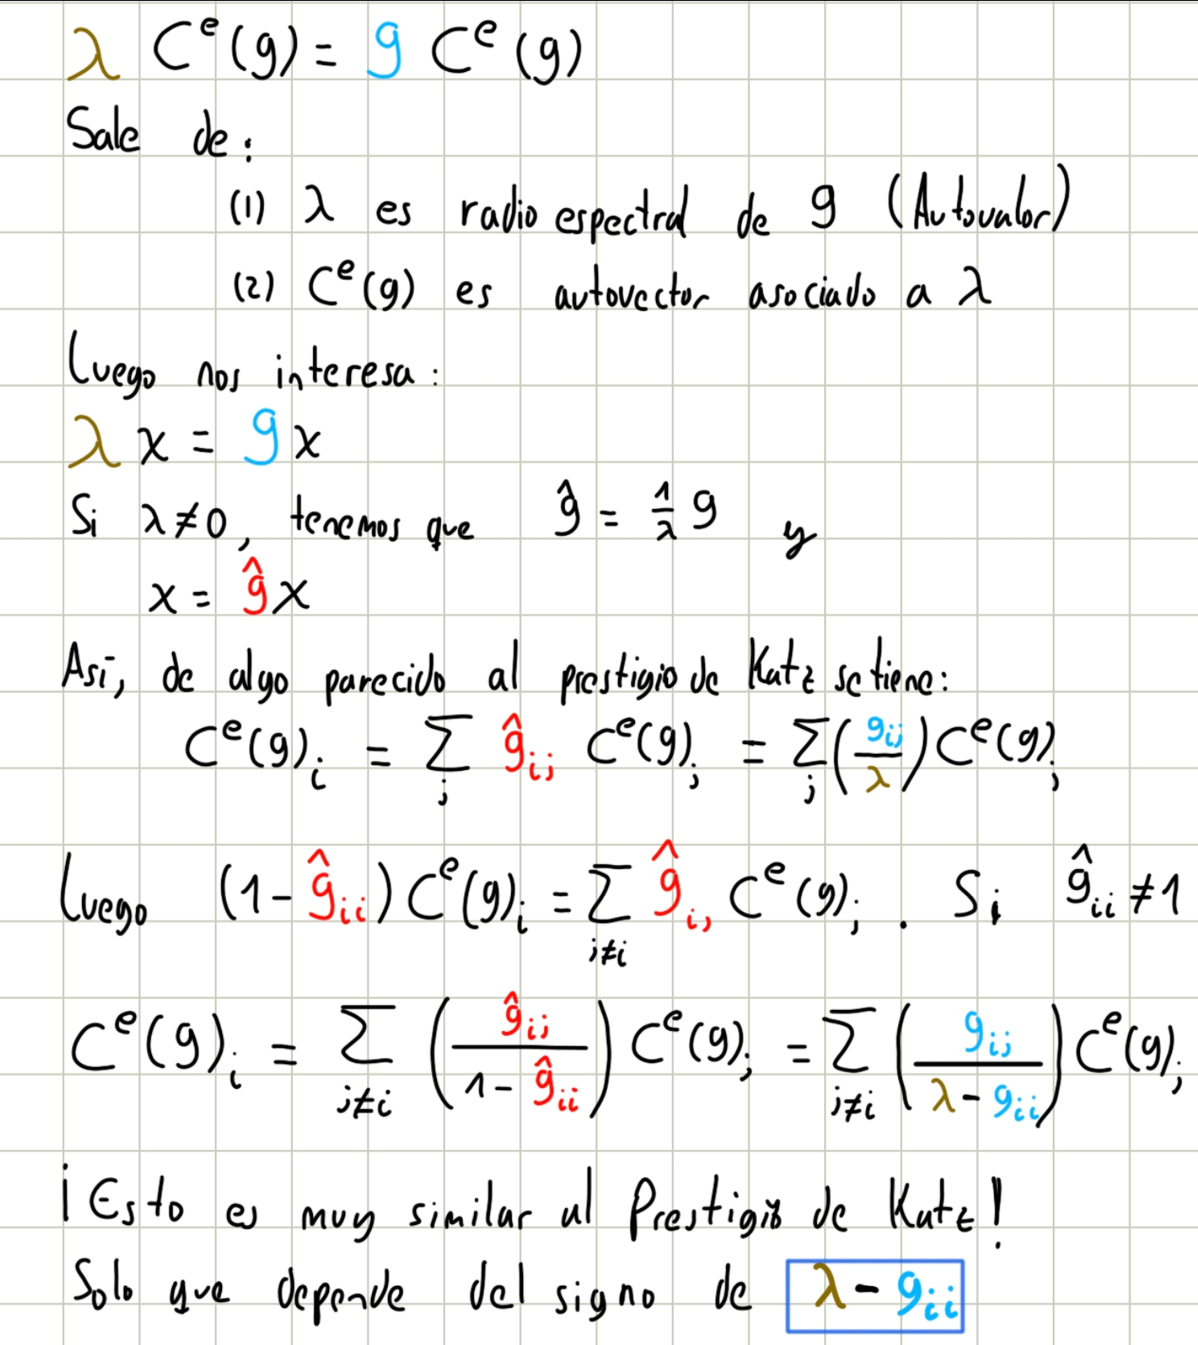

### Actividad en clase (Solo si queda tiempo)

Piense cómo implementaría el algoritmo de Newton-Raphson para implementar las medidas anteriores.